<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/CNN_treinamento_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#intalação
!pip install -q imgaug


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tensores
x_train = torch.tensor([[[[4,5,6,7], [5,6,7,8], [8,9,10,11], [4,6,7,8]]],[[[-4,5,6,-7], [5,-6,7,8], [-8,9,-10,11], [-4,-6,-7,-8]]]]).float().to(device)
x_train.div_(8)
y_train = torch.tensor([0,1]).float().to(device) # As classes

In [3]:
y_train.shape #mostra o formato do tensor de rótulos

torch.Size([2])

In [4]:
x_train.shape #mostra o formato do tensor de imagens

torch.Size([2, 1, 4, 4])

In [5]:
import torch.nn as nn
from torch.optim import Adam

def get_model():
    model = nn.Sequential(
        #camada convolucional: entra 1 canal, sai 1 canal, com filtro kernel
        nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3),
        nn.MaxPool2d(kernel_size=2),
        nn.ReLU(), #ativação que zera valores negativos
        nn.Flatten(), #achata o resultado 2D em um vetor 1D
        nn.Linear(1, 1), #camada totalmente conectada, de 1 entrada para 1 saída
        nn.Sigmoid() #transforma a saída em um valor entre 0 e 1
    ).to(device)

    loss_fn = nn.BCELoss()
    optimizer = Adam(model.parameters(), lr=0.01)

    return model, loss_fn, optimizer

In [6]:
model, criterion, optimizer = get_model()

In [7]:
model

Sequential(
  (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): ReLU()
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1, out_features=1, bias=True)
  (5): Sigmoid()
)

In [8]:
def train_batch(x, y, model, optimizer, loss_fn):
    model.train() #coloca o modelo em modo de treino
    optimizer.zero_grad()
    predictions = model(x) #→ faz a previsão passando x pelo modelo
    batch_loss = loss_fn(predictions.squeeze(), y.squeeze())
    batch_loss.backward()
    optimizer.step() #atualiza os pesos do modelo com base nos gradientes
    return batch_loss.item()

In [9]:
from torch.utils.data import DataLoader, TensorDataset, Dataset

trn_dl = DataLoader( #cria um carregador de dados para iterar sobre o dataset
    TensorDataset(x_train, y_train))

In [11]:
#reduzido para 800
for epoch in range(800):
    for ix, batch in enumerate(trn_dl):
        x, y = batch #percorre os lotes do DataLoader
        x, y = x.to(device), y.to(device) #garante que os dados estão no mesmo dispositivo do modelo
        loss = train_batch(x, y, model, optimizer, criterion)
        if ix % 100 == 0:
            print(f"Epoch {epoch}, Batch {ix}, Loss: {loss:.4f}")

Epoch 0, Batch 0, Loss: 0.0103
Epoch 1, Batch 0, Loss: 0.0103
Epoch 2, Batch 0, Loss: 0.0103
Epoch 3, Batch 0, Loss: 0.0103
Epoch 4, Batch 0, Loss: 0.0102
Epoch 5, Batch 0, Loss: 0.0102
Epoch 6, Batch 0, Loss: 0.0102
Epoch 7, Batch 0, Loss: 0.0102
Epoch 8, Batch 0, Loss: 0.0102
Epoch 9, Batch 0, Loss: 0.0101
Epoch 10, Batch 0, Loss: 0.0101
Epoch 11, Batch 0, Loss: 0.0101
Epoch 12, Batch 0, Loss: 0.0101
Epoch 13, Batch 0, Loss: 0.0101
Epoch 14, Batch 0, Loss: 0.0100
Epoch 15, Batch 0, Loss: 0.0100
Epoch 16, Batch 0, Loss: 0.0100
Epoch 17, Batch 0, Loss: 0.0100
Epoch 18, Batch 0, Loss: 0.0100
Epoch 19, Batch 0, Loss: 0.0099
Epoch 20, Batch 0, Loss: 0.0099
Epoch 21, Batch 0, Loss: 0.0099
Epoch 22, Batch 0, Loss: 0.0099
Epoch 23, Batch 0, Loss: 0.0099
Epoch 24, Batch 0, Loss: 0.0098
Epoch 25, Batch 0, Loss: 0.0098
Epoch 26, Batch 0, Loss: 0.0098
Epoch 27, Batch 0, Loss: 0.0098
Epoch 28, Batch 0, Loss: 0.0098
Epoch 29, Batch 0, Loss: 0.0097
Epoch 30, Batch 0, Loss: 0.0097
Epoch 31, Batch 0,

In [12]:
model(x_train[:1])

tensor([[0.0029]], grad_fn=<SigmoidBackward0>)

### Training

In [13]:
from torchvision import datasets
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_folder = './content'
#baixa e carrega o conjunto de treino
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets
#imagens e rótulos do treino
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.00MB/s]


In [14]:
def translate_images(images, max_shift=10):
    out = []
    for im in images:
        shift = np.random.randint(-max_shift, max_shift + 1)
        out.append(np.roll(im, shift, axis=1))
    return out

class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=False):
        self.x, self.y = x, y
        self.aug = aug  # booleano
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x, y
    def __len__(self): return len(self.x)

    def collate_fn(self, batch):
        'logic to modify a batch of images'
        ims, classes = list(zip(*batch))
        if self.aug:
            ims = translate_images([im.numpy() for im in ims])
        else:
            ims = [im.numpy() for im in ims]
        ims = torch.tensor(np.array(ims))[:, None, :, :].to(device) / 255.
        classes = torch.tensor(classes).to(device)
        return ims, classes

In [15]:
from torch.optim import Adam

def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3200, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer

In [16]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

In [17]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets, aug=True)
    trn_dl = DataLoader(train, batch_size=64,
                        collate_fn=train.collate_fn, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images),
                        collate_fn=val.collate_fn, shuffle=True)
    return trn_dl, val_dl

In [18]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

num_epochs = 5
for epoch in range(num_epochs):
    epoch_loss = 0
    for ix, batch in enumerate(trn_dl):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_loss += batch_loss
    epoch_loss /= len(trn_dl)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.6707
Epoch 2/5, Loss: 0.4543
Epoch 3/5, Loss: 0.3882
Epoch 4/5, Loss: 0.3543
Epoch 5/5, Loss: 0.3331


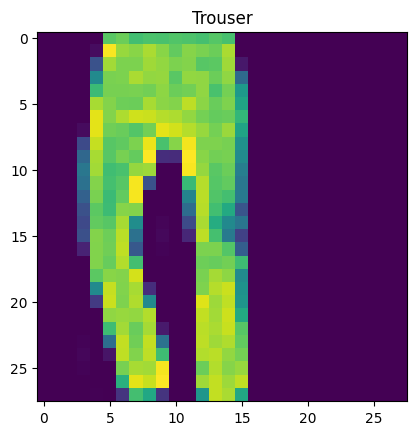

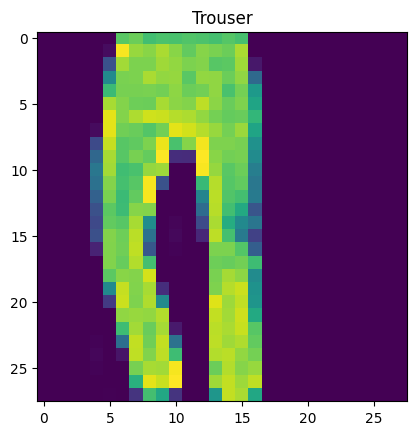

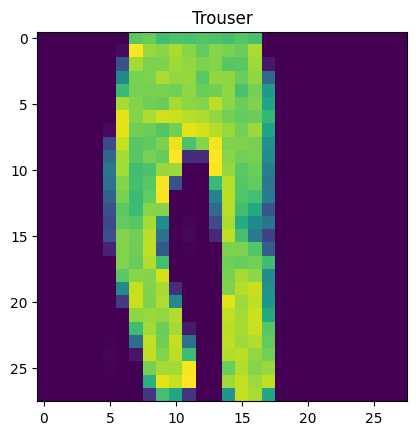

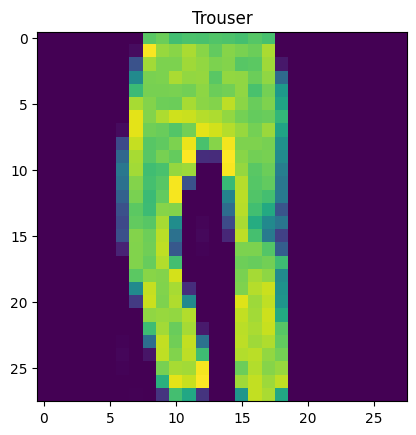

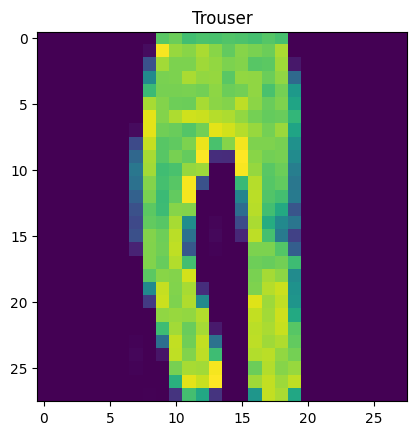

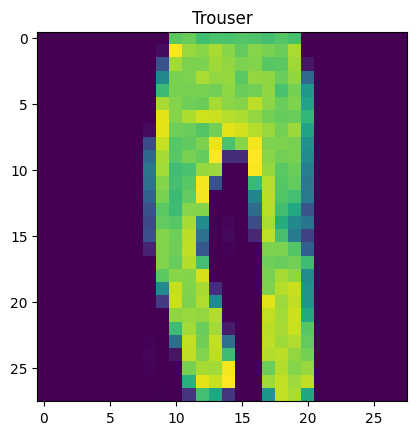

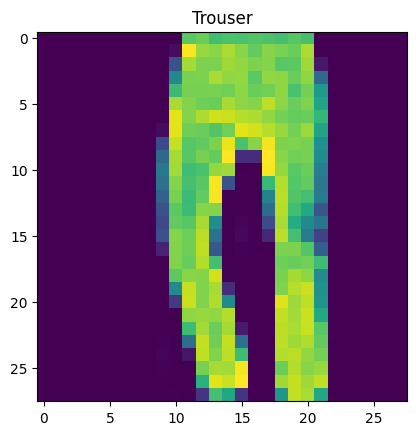

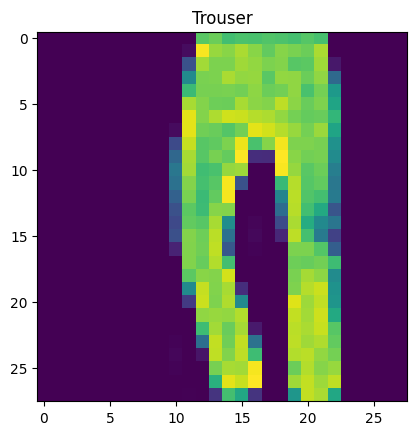

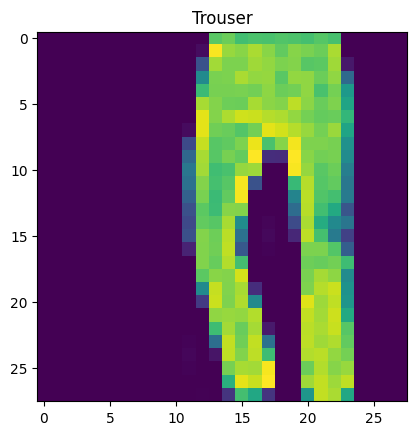

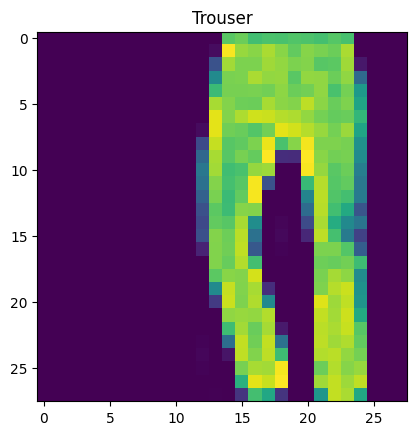

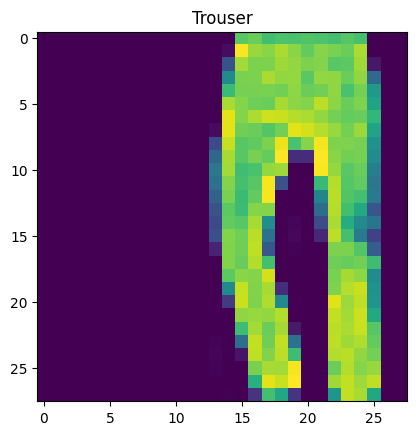

In [19]:
# inferência com o modelo treinado
model.eval()

preds = []
ix = 24300
for px in range(-5, 6):
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1, 1, 28, 28).to(device)
    np_output = model(img3).cpu().detach().numpy()
    pred = np.exp(np_output)/np.sum(np.exp(np_output))
    preds.append(pred)
    plt.imshow(img2)
    plt.title(fmnist.classes[pred[0].argmax()])
    plt.show()